# Training of a Serial Quantum Fourier model
Compatible with Qiskit 1.02+

### Author
- **Jacob Cybulski**, jacob.cybulski[at]deakin.edu.au<br/>
    School of IT, SEBE, Deakin University, Melbourne, Vic, Australia

### Date
- October 2022: Prepared for Workshop on Quantum Machine Learning, 13 October 2022, <br/>
  organised in collaboration with QWorld, QPoland, QIndia and Quantum AI Foundation.<br/>
  In assoc. with IEEE Conf Trends in Quantum Computing and Emerging Business Technologies TQCEBT'2022
- May 2024: Compatibility upgrade to Qiskit 1.02 
- Feb 2025: Addition of random iterations

### Aims
> *This script aims to create a single qubit serial variational model to fit some data and provide a forecast.*

### Note
> *<font color="tomato">When running this script, you are likely to obtain slightly different results each time.</font>*

### Primary Sources
- Schuld, Maria, Ryan Sweke, and Johannes Jakob Meyer. <br/>
    "The Effect of Data Encoding on the Expressive Power of Variational Quantum Machine Learning Models." <br/>
    *Physical Review A 103*, no. 3 (March 24, 2021): 032430.<br/> 
    http://arxiv.org/abs/2008.08605<br/>
- PennyLane Dev Team. "Quantum models as Fourier series", Last updated: 15 Jan 2021.<br/>
    https://pennylane.ai/qml/demos/tutorial_expressivity_fourier_series.html

In [1]:
import sys
sys.path.append('.')
sys.path

['/home/jacob/miniconda3/envs/qiskit-gpu/lib/python311.zip',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/site-packages',
 '.']

In [2]:
import os
import numpy as np
import pylab
import math
import json
import time
import copy
from tqdm.notebook import tqdm

from IPython.display import clear_output

from utils.Target import *
from utils.Charts import *
from utils.Files import *
from utils.Cost import *
from utils.Models import *

import matplotlib.pyplot as plt
from matplotlib import set_loglevel
set_loglevel("error")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.filterwarnings("ignore", category=UserWarning) 

## Create sample models

### Sample serial model

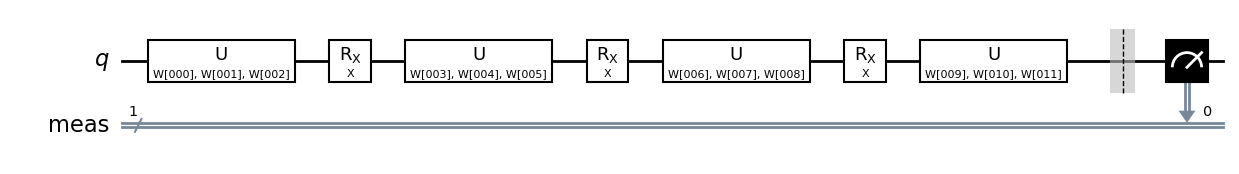

In [3]:
### Show a sample serial model with the specified number of layers
m = serial_fourier_model(3, add_meas=True)
print()
# print(m.draw(output='latex_source', style='bw', scale=1, fold=True))
m.draw(output='mpl', style='bw', scale=1, fold=True);

### Sample parallel model

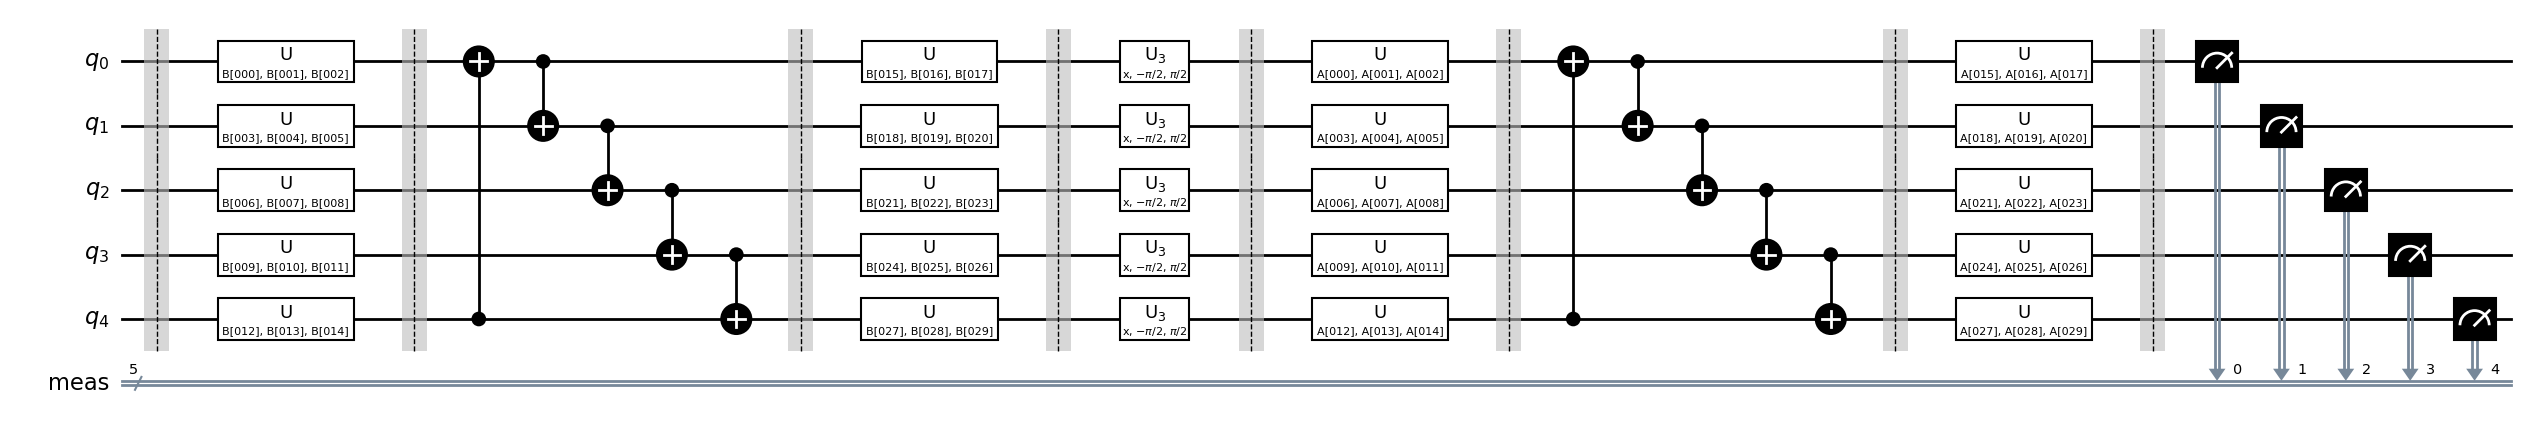

In [4]:
# Sample parallel model with q qubits, BL layers before and BA layers after
# - Note that S block is identical for all qubits
m = parallel_fourier_model(5, 1, 1, add_meas=True)
print()
# print(m.draw(output='latex_source', style='bw', scale=1, fold=True))
m.draw(output='mpl', style='bw', scale=1, fold=True);

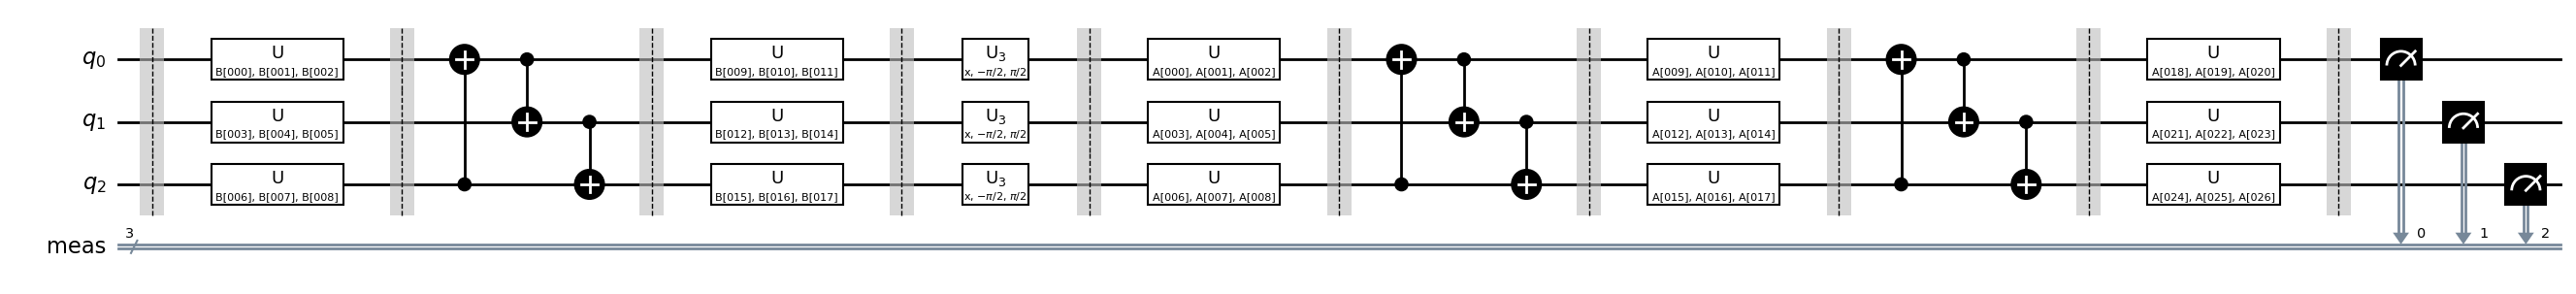

In [5]:
# Sample parallel model with q qubits, BL layers before and BA layers after
# - Note that S block is identical for all qubits
m = parallel_fourier_model(3, 1, 2, add_meas=True)
print()
# print(m.draw(output='latex_source', style='bw', scale=1, fold=True))
m.draw(output='mpl', style='bw', scale=1, fold=True);

### Sample xparallel model

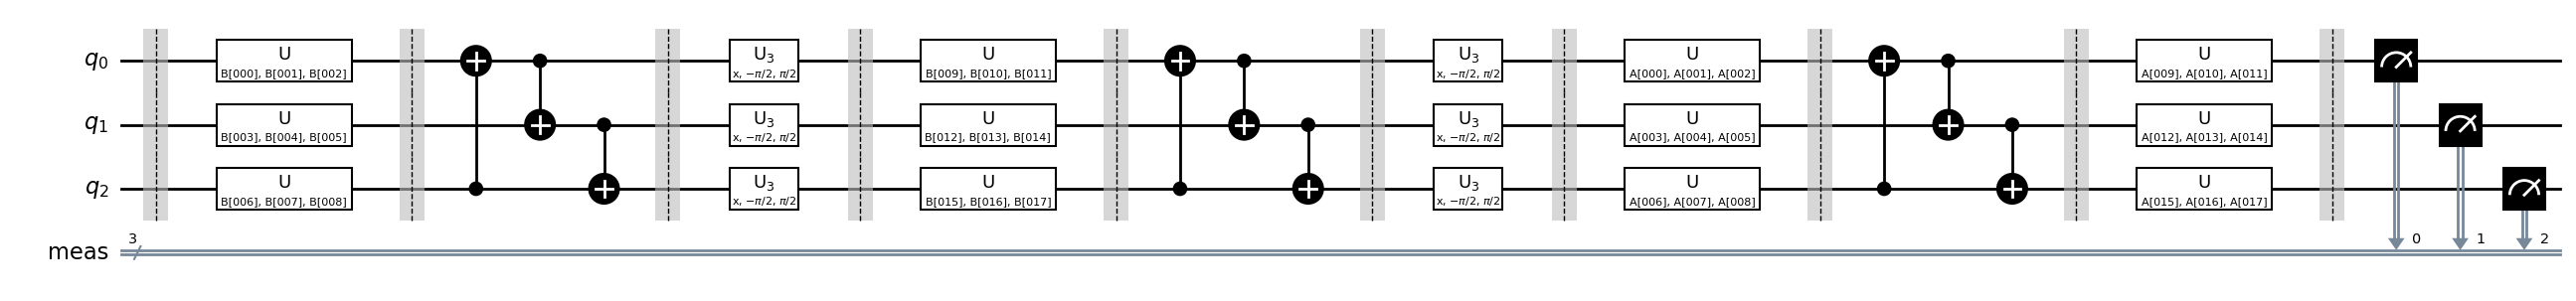

In [6]:
# Sample parallel model with q qubits, BL layers before and BA layers after
# - Note that S block is identical for all qubits
m = parallel_fourier_model_with_reuploading(3, 2, 1, add_meas=True)
m.draw(output='mpl', style='bw', scale=1, fold=True);

### Sample xqnn model


Example: Inputs#=5, Qubits#=7, Weight params#=63, FM Layer#=1, ANZ Layer#=2




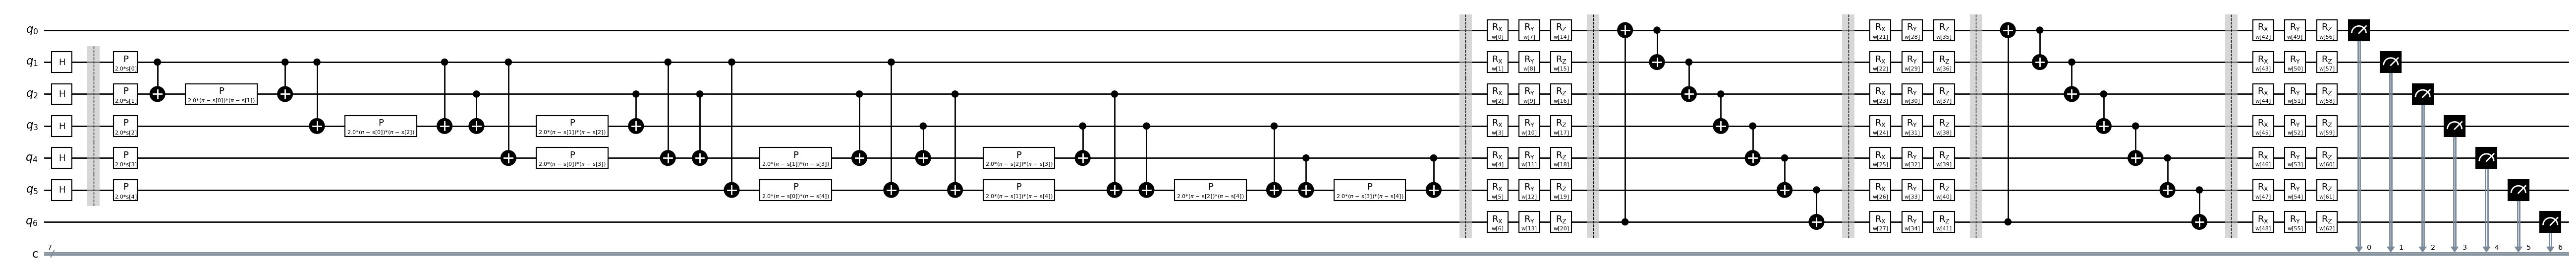

In [9]:
# Test a sample QNN model
test_qubits = 7; test_inputs= 5; test_fm_layers = 1; test_anz_layers = 2; test_ent = 'circular'
test_m, test_input_params, test_weight_params = \
    swindow_qnn_model(test_qubits, test_inputs, test_fm_layers, test_anz_layers, ent=test_ent, add_meas=True, observable='global')

print(f'\nExample: Inputs#={len(test_input_params)}, Qubits#={test_qubits}, Weight params#={len(test_weight_params)}, FM Layer#={test_fm_layers}, ANZ Layer#={test_anz_layers}')

print()
test_m.draw(output='mpl', style='bw', fold=False, scale=1)
print()


Example: Qubits#=7, Inputs#=5, Weight params#=63, FM Layer#=1, ANZ Layer#=2


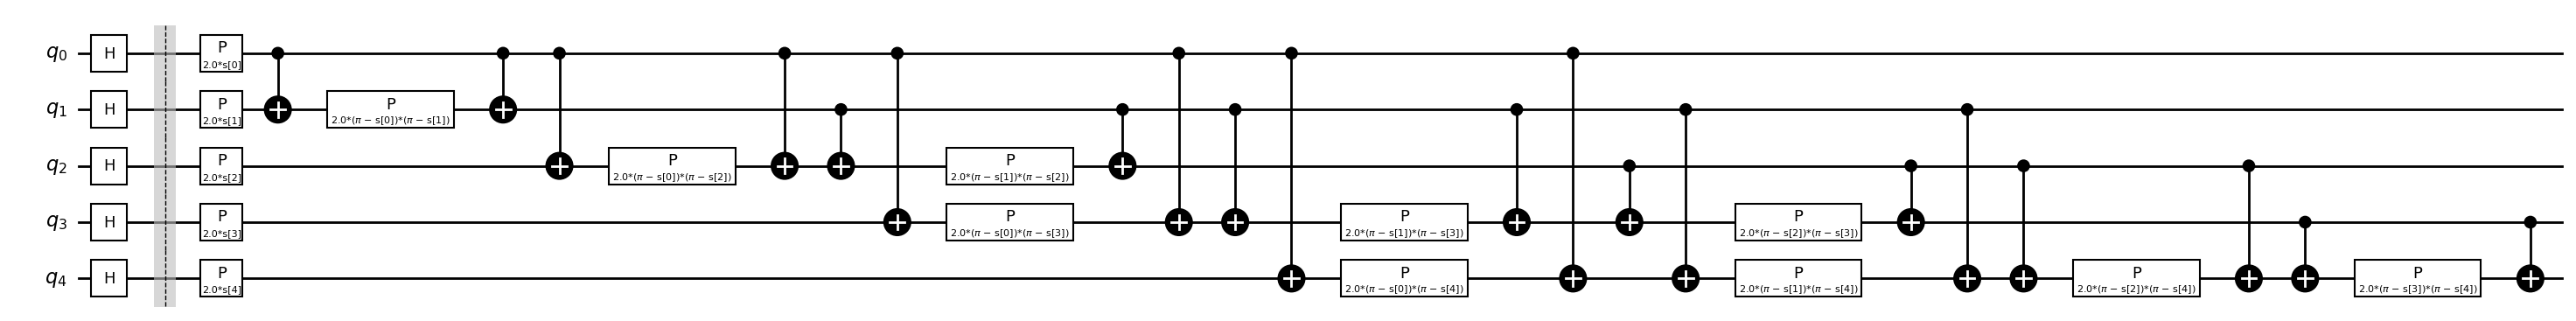

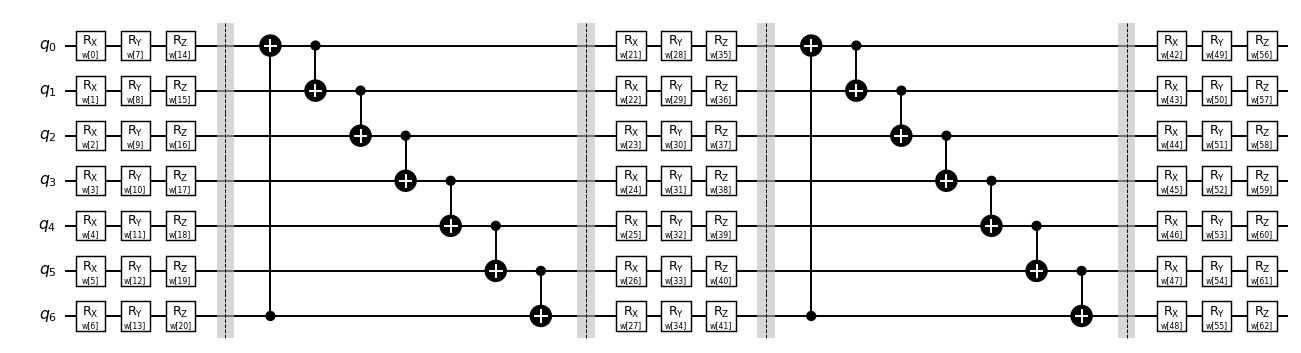

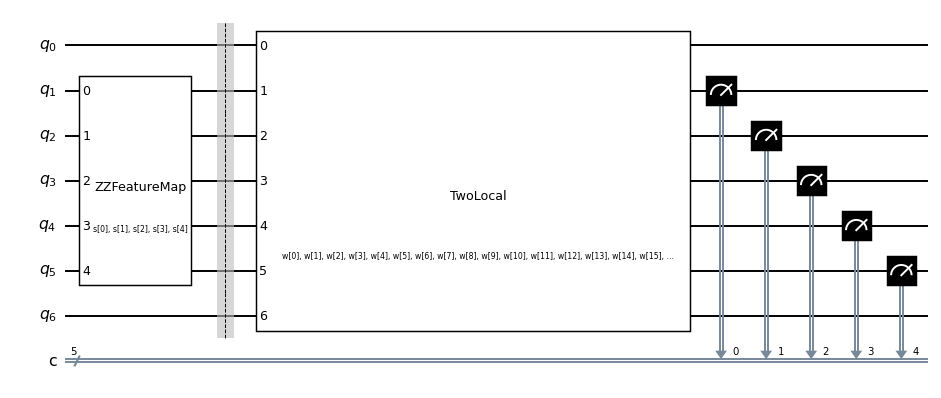

In [7]:
# Test a sample QNN model
test_qubits = 7; test_inputs= 5; test_fm_layers = 1; test_anz_layers = 2; test_ent = 'circular'
fm, ansatz, circ = \
    swindow_qnn_model(test_qubits, test_inputs, test_fm_layers, test_anz_layers, ent=test_ent, add_meas=True, return_components=True)

print(f'\nExample: Qubits#={test_qubits}, Inputs#={len(fm.parameters)}, Weight params#={len(ansatz.parameters)}, '+\
      f'FM Layer#={test_fm_layers}, ANZ Layer#={test_anz_layers}')

fm.decompose().draw(output='mpl', style='bw', fold=False, scale=1)
ansatz.decompose().draw(output='mpl', style='bw', fold=False, scale=0.7)
circ.decompose().draw(output='mpl', style='bw', fold=False, scale=0.7);

### Sample overloading model


Input params#: 10, Weight params#: 54, Layer#: x1 * i2 = 2



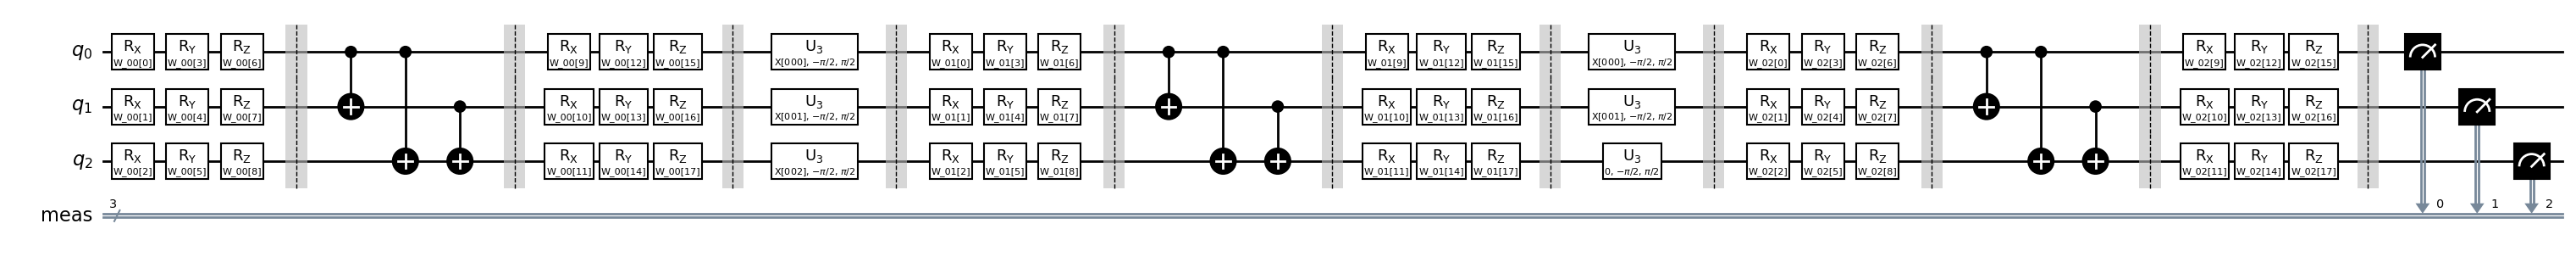

In [8]:
### Test a sample serial ansatz
qubits_no = 3; input_no = 5; xlayers = 1
m, input_params, weight_params, ilayers = swindow_serial_model(qubits_no, input_no, xlayers, ent='full', add_meas=True)

# print(f'Layers: {ilayers}\nParams: {m.parameters}\n')
# print('Input params:\n', input_params)
# print('\nWeight params:\n', weight_params)
print(f'\nInput params#: {len(input_params)}, Weight params#: {len(weight_params)}, Layer#: x{xlayers} * i{ilayers} = {xlayers*ilayers}')

m.draw(output='mpl', style='bw', fold=False, scale=1)
print()

## System

In [9]:
import sys
print(f'\nEnvironment:\n\n{sys.prefix}\n')


Environment:

/home/jacob/miniconda3/envs/qiskit-gpu



In [10]:
import os
print(f"\nSignificant packages:\n")
os.system('pip list | grep -e qiskit');


Significant packages:

qiskit                        1.2.4
qiskit-aer-gpu                0.15.1
qiskit-algorithms             0.3.1
qiskit-ibm-runtime            0.32.0
qiskit-machine-learning       0.8.1
qiskit-optimization           0.6.1
qiskit-sphinx-theme           1.16.1
